In [47]:

import numpy as np

from Kea.statistics.spectra import per_spectra, spectra_base, strfn_spectra
from Kea.statistics.statfunc import statfunc_base, strfn
from Kea.statistics import statistics_base
from Kea.utils import plotting, data_writer

import h5py as h5

import time

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
plotting.modify_rc()


In [48]:

SCALINGS = [
    {'N': 128, 'P': 32, 'D': 3, 'T': 154.72, 'class': 'FBM'},
    {'N': 128, 'P': 64, 'D': 3, 'T': 88.6964, 'class': 'FBM'},
    {'N': 128, 'P': 128, 'D': 3, 'T': 66.8281, 'class': 'FBM'},

    #{'N': 256, 'P': 32, 'D': 3, 'T': None, 'class': 'FBM'},
    {'N': 256, 'P': 64, 'D': 3, 'T': 10527.2, 'class': 'FBM'},
    {'N': 256, 'P': 128, 'D': 3, 'T': 4808.77, 'class': 'SIM'},

    {'N': 512, 'P': 128, 'D': 3, 'T': 170511., 'class': 'FBM'},

    {'N': 512, 'P': 32, 'D': 2, 'T': 4.81686, 'class': 'FBM'},
    {'N': 512, 'P': 64, 'D': 2, 'T': 3.5082, 'class': 'FBM'},

    {'N': 1024, 'P': 32, 'D': 2, 'T': 92.557, 'class': 'FBM'},
    {'N': 1024, 'P': 64, 'D': 2, 'T': 80.8716, 'class': 'FBM'},

    {'N': 2048, 'P': 64, 'D': 2, 'T': 473.14, 'class': 'SIM'},
    #{'N': 2048, 'P': 128, 'D': 2, 'T': 766.079, 'class': 'SIM'},
    #{'N': 2048, 'P': 128, 'D': 2, 'T': 1781.56, 'class': 'SIM'},
    #{'N': 2048, 'P': 128, 'D': 2, 'T': 715.656, 'class': 'SIM'},

    #{'N': 4096, 'P': 32, 'D': 2, 'T': None, 'class': 'FBM'},
    {'N': 4096, 'P': 64, 'D': 2, 'T': 10263.5, 'class': 'FBM'},

]


[  1.73470491 -19.93345981] [  1.89387028 -22.42527265] [  1.88618706 -23.13543397]
Estimated time for 1024^3, 64 cores: 267.7114678533883 [days]
Estimated time for 1024^3, 128 cores: 112.16603946923863 [days]


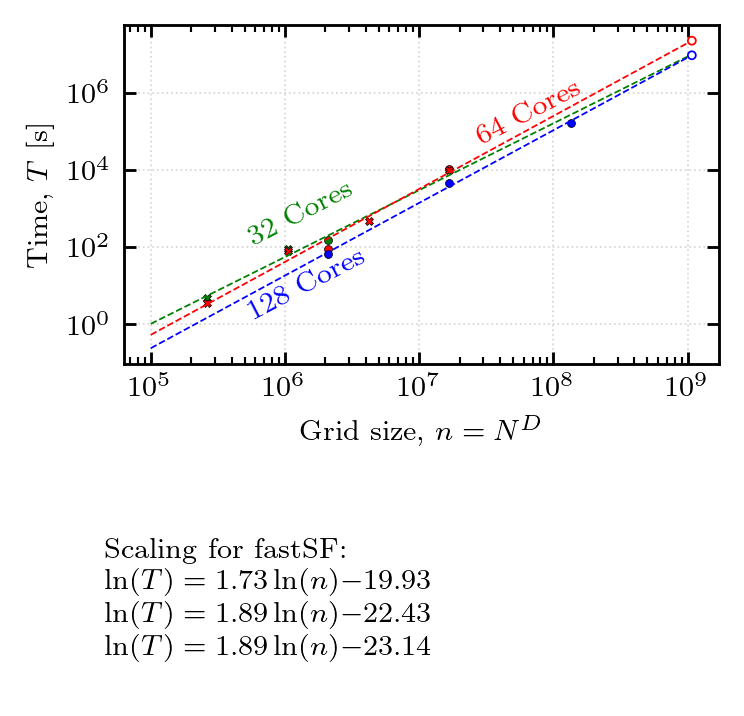

In [49]:

fig, ax = plt.subplots(1, 1, figsize=(3., 1.75), dpi=256)

#markers = {'FBM': 'X', 'SIM': 'o'}
markers = {1: 'v', 2: 'X', 3: 'o'}
colors = {32: 'green', 64: 'red', 128: 'blue'}

x_all, y_all = [], []
x_32, y_32 = [], []
x_64, y_64 = [], []
x_128, y_128 = [], []

for s in SCALINGS:
    x_all.append(s['N']**s['D'])
    y_all.append(s['T'])

    if s['P'] == 32:
        x_32.append(x_all[-1])
        y_32.append(y_all[-1])
    elif s['P'] == 64:
        x_64.append(x_all[-1])
        y_64.append(y_all[-1])
    elif s['P'] == 128:
        x_128.append(x_all[-1])
        y_128.append(y_all[-1])

    ax.scatter(s['N']**s['D'], s['T'], marker=markers[s['D']], s=5., color=colors[s['P']], zorder=2, linewidth=0.2, edgecolor='black')

f_all = np.polyfit(np.log(x_all), np.log(y_all), deg=1)
p_all = np.poly1d(f_all)

f_32 = np.polyfit(np.log(x_32), np.log(y_32), deg=1)
p_32 = np.poly1d(f_32)
f_64 = np.polyfit(np.log(x_64), np.log(y_64), deg=1)
p_64 = np.poly1d(f_64)
f_128 = np.polyfit(np.log(x_128), np.log(y_128), deg=1)
p_128 = np.poly1d(f_128)

print(f_32, f_64, f_128)

C = ['green', 'red', 'blue']
N = 10**np.linspace(np.log10(1e5), np.log10(1e9), 1000)
for i, f in enumerate([p_32, p_64, p_128]):
    ax.plot(N, np.exp(f(np.log(N))), linewidth=0.5, linestyle='--', color=C[i])

t_est_64 = np.exp(p_64(np.log(1024**3)))
t_est_128 = np.exp(p_128(np.log(1024**3)))
print('Estimated time for 1024^3, 64 cores:', t_est_64/60./60./24., '[days]')
print('Estimated time for 1024^3, 128 cores:', t_est_128/60./60./24., '[days]')
ax.scatter(1024**3, t_est_64, marker=markers[3], s=5., color='none', zorder=2, linewidth=0.5, edgecolor='red')
ax.scatter(1024**3, t_est_128, marker=markers[3], s=5., color='none', zorder=2, linewidth=0.5, edgecolor='blue')

props = dict(boxstyle='Square', edgecolor='none', linewidth=1., facecolor='none', alpha=0.2)
ax.text(5e5, 0.35, '32 Cores', color='green', transform=ax.get_xaxis_transform(), bbox=props, rotation=27.5)
ax.text(2.5e7, 0.65, '64 Cores', color='red', transform=ax.get_xaxis_transform(), bbox=props, rotation=27.5)
ax.text(5e5, 0.13, '128 Cores', color='blue', transform=ax.get_xaxis_transform(), bbox=props, rotation=27.5)

ax.set_yscale('log')
ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_ylabel('Time, $T$ [s]')
ax.set_xlabel('Grid size, $n=N^D$')

txt = r'''
Scaling for fastSF:
$\ln(T)={%s}\ln(n){%s}$
$\ln(T)={%s}\ln(n){%s}$
$\ln(T)={%s}\ln(n){%s}$
''' % (f_32[0].round(decimals=2), f_32[1].round(decimals=2), f_64[0].round(decimals=2), f_64[1].round(decimals=2), f_128[0].round(decimals=2), f_128[1].round(decimals=2))
fig.text(0.1, -0.2, txt, wrap=True, horizontalalignment='left', verticalalignment='top')

fig.savefig('fastSF_scaling.pdf', bbox_inches='tight', pad_inches=0)


In [55]:
print(np.exp(f_32[1])/np.exp(f_64[1]), np.exp(f_64[1])/np.exp(f_128[1]))

12.083161232401768 2.0343194017157704


In [54]:
## REQUIRE MEMORY

P = 128
px = 32

Nx = 2048
Ny = 1
Nz = 2048

n = 1

# formulae
M2_s = (20 + 4*n)*Nx*Nz + 8*(Nx/px + Nz*px/P) + 32*P
M3_s = (16 + 2*n)*Nx*Ny*Nz + 4*Nx*Ny + 8*(Nx/px + Nz*px/P) + 40*P

M2_v = (44 + 8*n)*Nx*Nz + 8*(Nx/px + Nz*px/P) + 40*P
M3_v = (56 + 4*n)*Nx*Ny*Nz + 4*Nx*Ny + 8*(Nx/px + Nz*px/P) + 48*P

# IN GB
print(M3_s/1000/1000/1000, 'GB')
print(P*M3_s/1000/1000/1000, 'GB')


0.075515392 GB
9.665970176 GB
